(a , b) L=18 and L=30 G-dist plots function

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def quasi_discrete_bins(x, xmin=20.0):
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    vals = np.sort(np.unique(np.round(x, 8)))

    # only use values at/above xmin to define the bins
    vals = vals[vals >= xmin]

    if len(vals) < 2:
        v = vals[0]
        return np.array([xmin, v + 1.0])

    diffs = np.diff(vals)
    diffs = diffs[diffs > 0]
    step = np.median(diffs) if len(diffs) else 1.0

    edges = np.empty(len(vals) + 1)
    edges[0] = xmin
    edges[1:-1] = (vals[:-1] + vals[1:]) / 2
    edges[-1] = vals[-1] + step / 2

    # enforce strictly increasing edges
    eps = max(1e-9, step * 1e-6)
    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = edges[i - 1] + eps

    return edges


data_path = "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/samVDD/RNA_complexity_data.dat"

# tab-separated file
df = pd.read_csv(data_path, sep="\t", low_memory=False)
print(df.shape)
df.head()

# Keep only the random genotype ensemble (sequence null model)
df_random = df[df["Dataset"] == "SeqNull"].copy()


def plot_compare_rna_top(
    ax,
    file_L18,
    file_L30,
    label_18="L=18",
    label_30="L=30",
):
    files = {
        label_18: file_L18,
        label_30: file_L30,
    }

    colors = {
        label_18: "#2171b5",   # light blue
        label_30: "#08306b",   # dark blue
    }

    def load_rna_freq(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()

        required = {"Status", "Complexity", "Freq"}
        if not required.issubset(df.columns):
            raise ValueError(f"Expected columns {required} in {path}")

        df = df[df["Status"] == "Rand"].copy()
        df["Complexity"] = pd.to_numeric(df["Complexity"], errors="coerce")
        df["Freq"] = pd.to_numeric(df["Freq"], errors="coerce")
        df = df.dropna()
        return df

    def grouped_probabilities(df):
        grouped = df.groupby("Complexity")["Freq"].sum().sort_index()
        x = grouped.index.to_numpy(dtype=float)
        y = grouped.values.astype(float)
        y = y / y.sum() if y.sum() > 0 else y
        return x, y

    data = {label: load_rna_freq(path) for label, path in files.items()}

    x18, p18 = grouped_probabilities(data[label_18])
    x30, p30 = grouped_probabilities(data[label_30])

    # Main panel
    ax.fill_between(
        x18,
        p18,
        step="mid",
        alpha=0.35,
        color=colors[label_18],
        label=label_18,
    )
    #ax.step(
    #    x18,
    #    p18,
    #    where="mid",
    #    linewidth=1.8,
    #    color=colors[label_18]
    #)

    ax.fill_between(
        x30,
        p30,
        step="mid",
        alpha=0.35,
        color=colors[label_30],
        label=label_30,
    )
    #ax.step(
    #    x30,
    #    p30,
    #    where="mid",
    #    linewidth=1.8,
    #    color=colors[label_30]
    #)

    ax.set_xlabel("Complexity (Lempel-Ziv)")
    ax.set_ylabel("Probability")

    # Inset: length distributions
    lengths_to_plot = [50, 100, 200, 300, 500]
    inset_colors = plt.cm.GnBu(np.linspace(0.35, 0.95, len(lengths_to_plot)))

    axins = inset_axes(
        ax,
        width="34%",
        height="40%",
        loc="upper right",
        borderpad=1.0,
    )

    for color, L in zip(inset_colors, lengths_to_plot):
        subset = df_random[df_random["Length"] == L]
        x = subset["Structural complexity"].dropna().values

        if len(x) == 0:
            continue

        edges = quasi_discrete_bins(x)
        weights = np.ones_like(x) / len(x)

        axins.hist(
            x,
            bins=edges,
            weights=weights,
            histtype="stepfilled",
            alpha=0.65,
            color=color,
            edgecolor="0.15",
            linewidth=0.5,
            label=f"L={L}",
        )

    axins.set_xscale("log")
    axins.set_xlim(17, 1e3)
    axins.tick_params(labelsize=8)
    axins.set_xlabel("")
    axins.set_ylabel("")

    ax.legend(
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0.15, 0.97),
        fontsize=9,
        handlelength=1.4,
        borderaxespad=0.0,
    )

    axins.legend(
        frameon=False,
        fontsize=7,
        title_fontsize=7,
        loc="upper right",
        bbox_to_anchor=(1.0, 1.02),
        handlelength=1.0,
        labelspacing=0.2,
    )

    ax.tick_params(labelsize=12)
    return ax

(227587, 29)


plot C Function

In [102]:
def plot_C(ax):
    """
    RNA L=30 — Plot C
    Mean complexity vs Shannon entropy (linear regression).
    """

    import numpy as np
    import pandas as pd
    from pathlib import Path

    data_path = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/"
        "circadian/mut_project_updates/figures/RNA/"
        "plot_c/plot_c_files/Plot_C_data_RNA_N_Million_Samples.xlsx"
    )

    df = pd.read_excel(data_path)

    df["L"] = pd.to_numeric(df["L"], errors="coerce")
    df["S"] = pd.to_numeric(df["S"], errors="coerce")
    df["Kg"] = pd.to_numeric(df["Kg"], errors="coerce")

    df = df.dropna()

    entropy_vals = df["S"].values
    kg_vals = df["Kg"].values
    labels = df["L"].astype(int).astype(str).values

    # Linear regression
    m, b = np.polyfit(entropy_vals, kg_vals, 1)
    fit_line = m * entropy_vals + b
    sign = "-" if b < 0 else "+"
    eq_label = rf"$\langle \tilde{{K}}_{{g}} \rangle = {m:.2f}\,S {sign} {abs(b):.2f}$"

    ax.scatter(entropy_vals, kg_vals, color='darkblue')
    ax.plot(entropy_vals, fit_line, color='darkblue', label=eq_label)

    for xi, yi, lbl in zip(entropy_vals, kg_vals, labels):
        ax.text(xi, yi, lbl, ha='center', va='bottom', fontsize=11)

    ax.set_xlabel("Shannon Entropy (S)")
    ax.set_ylabel(r"Mean Complexity $\langle \tilde{K}_{g} \rangle$")
    ax.margins(x=0.05, y=0.05)
    ax.legend(fontsize=12,frameon=False)

plot D Function

In [103]:
def plot_D(ax):
    """
    RNA L=30 — Plot D
    Mean G1..G5 vs mutation number.
    """

    import numpy as np
    import pandas as pd
    from pathlib import Path

    csv_path = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
        "mut_project_updates/figures/RNA/L_30/plot_d/plot_d_files/"
        "RNA_L30_k_scaled_1_for_plot_D.csv"
    )

    marker = "o"
    marker_size = 6

    # --------------------------------
    # Load CSV
    # --------------------------------
    df = pd.read_csv(csv_path)
    if df.empty:
        raise RuntimeError(f"No data found in {csv_path}")

    first_col = df.columns[0]
    first_col_lower = first_col.lower()

    if any(k in first_col_lower for k in ("mut", "number", "n", "k")):
        x_vals = df.iloc[:, 0].to_numpy()
        data_df = df.iloc[:, 1:].copy()
    else:
        x_vals = np.arange(len(df))
        data_df = df.copy()

    # Find MeanG* columns
    meang_cols = [
        c for c in data_df.columns
        if str(c).lower().startswith("meang")
    ]

    if not meang_cols:
        meang_cols = [
            c for c in data_df.columns
            if any(s in str(c).lower() for s in ("g1","g2","g3","g4","g5"))
        ]

    if not meang_cols:
        raise RuntimeError("No MeanG* columns found in CSV.")

    # Prepare arrays
    series_vals = []
    for c in meang_cols:
        vals = pd.to_numeric(data_df[c], errors="coerce").to_numpy()
        series_vals.append(vals)

    series_vals = np.array(series_vals)

    # x positions
    x_positions = np.arange(len(x_vals))

    if np.issubdtype(x_vals.dtype, np.number):
        x_tick_labels = [
            str(int(x)) if float(x).is_integer() else f"{x:.3g}"
            for x in x_vals
        ]
    else:
        x_tick_labels = [str(x) for x in x_vals]

    # --------------------------------
    # Plot
    # --------------------------------
    palette = [
        "#B8D8F8",
        "#7FB3E6",
        "#4F8FCC",
        "#2F5F99",
        "#163B66",
    ]
    
    for i, vals in enumerate(series_vals):
        ax.plot(x_positions,
                vals,
                marker=marker,
                label=f"G{i+1}",
                color=palette[i])

    ax.set_xlabel("Number of mutations")
    ax.set_ylabel(r"Mean Complexity $\langle \tilde{K}_{g} \rangle$")

    # show every other tick
    ax.set_xticks(x_positions[::2])
    ax.set_xticklabels(x_tick_labels[::2])

    ax.grid(True, which="major", linestyle="-", alpha=0.2)

    # Reverse legend (G5 → G1)
    handles, legend_labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], legend_labels[::-1],
              loc="upper right",fontsize=10,frameon=False)

    # 0.5 tick spacing margin
    if len(x_positions) > 1:
        spacing = x_positions[1] - x_positions[0]
    else:
        spacing = 1.0

    ax.set_xlim(x_positions[0] - 0.25 * spacing,
                x_positions[-1] + 0.5 * spacing)

/var/folders/yr/bzwkxpcj34x73kc2trlk0h2m0000gn/T/ipykernel_93016/3986683299.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


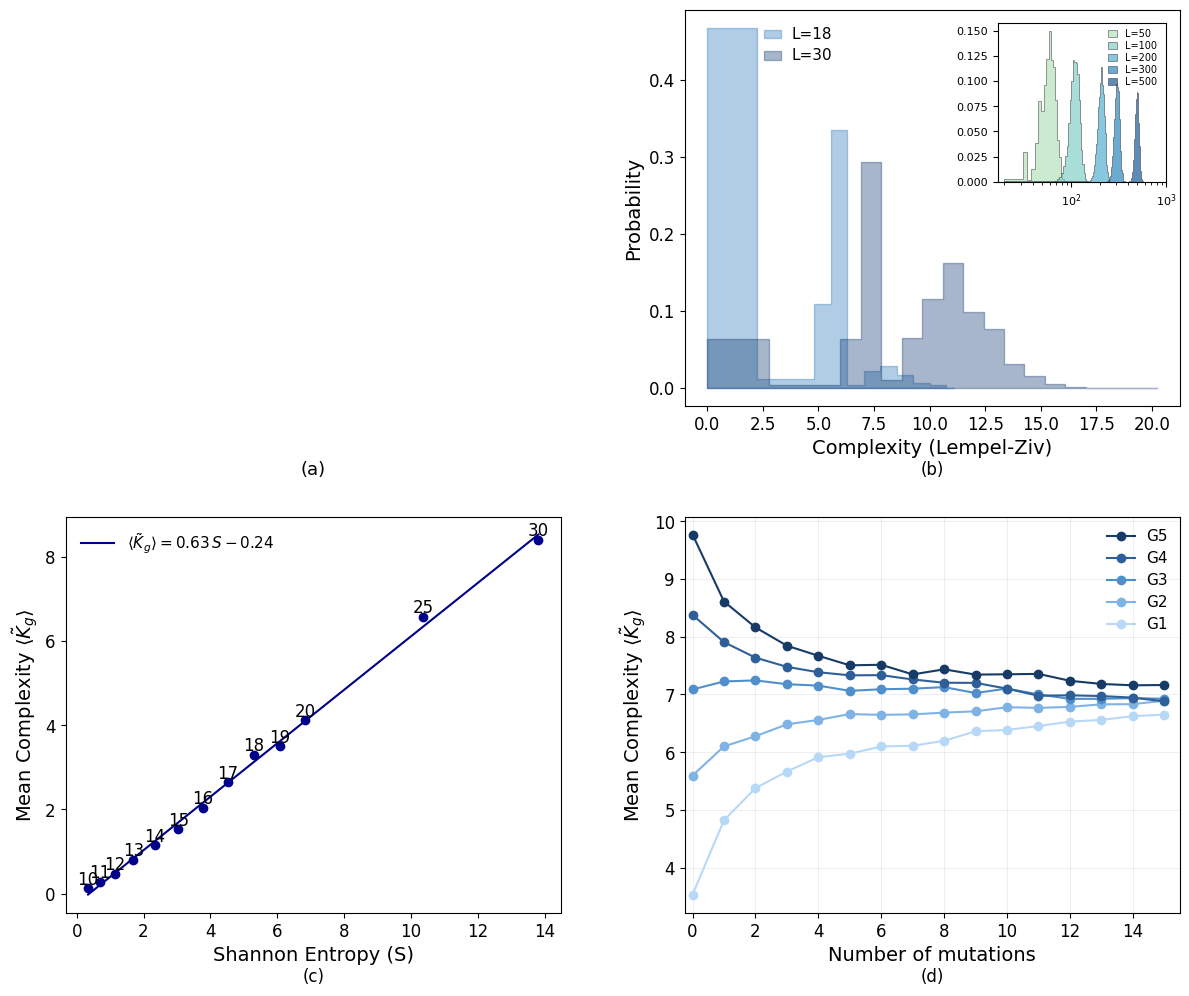

In [104]:
import matplotlib.pyplot as plt

# ===================================
# Paths
# ===================================
path_L18 = "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_18/plot_a/plot_a_files/Plot_A_RNA_L18_Billion_Samples.csv"
path_L30 = "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_30/plot_a/plot_a_files/Plot_A_RNA_L30_Billion_Samples.csv"

# ===================================
# Figure layout: empty upper-left, plots in the rest
# ===================================
fig = plt.figure(figsize=(12, 10))

ax_blank = plt.subplot2grid((2, 2), (0, 0))
ax_top = plt.subplot2grid((2, 2), (0, 1))
ax_bl = plt.subplot2grid((2, 2), (1, 0))
ax_br = plt.subplot2grid((2, 2), (1, 1))

ax_blank.axis("off")

ax_blank.text(
    0.5, -0.14, "(a)",
    transform=ax_blank.transAxes,
    ha="center", va="top",
    fontsize=13
)

# ===================================
# Top-right panel: RNA comparison
# ===================================
plot_compare_rna_top(
    ax_top,
    path_L18,
    path_L30,
)

# ===================================
# Bottom panels
# ===================================
plot_C(ax_bl)
plot_D(ax_br)

# ===================================
# Panel labels
# ===================================
axes = [ax_top, ax_bl, ax_br]
panel_labels = ['(b)', '(c)', '(d)']

for ax, label in zip(axes, panel_labels):
    ax.text(
        0.5, -0.14, label,
        transform=ax.transAxes,
        ha='center', va='top',
        fontsize=13
    )

# ===================================
# Styling
# ===================================
LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 11
ANNOT_SIZE = 12

for ax in axes:
    ax.xaxis.label.set_size(LABEL_SIZE)
    ax.yaxis.label.set_size(LABEL_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)

    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(LEGEND_SIZE)

    for text in ax.texts:
        text.set_fontsize(ANNOT_SIZE)

# ===================================
# Title + spacing
# ===================================
plt.tight_layout()
plt.subplots_adjust(hspace=0.28, wspace=0.25)

plt.show()

simplicity bias function (if you need it later)

In [105]:
def plot_simplicity_bias(ax, file_path, a=0.2, b=2.5):
    import numpy as np

    data = np.loadtxt(file_path)

    x = data[:, 0]
    y = data[:, 1]

    # Clean
    mask = (~np.isnan(y)) & (y > 0)
    x = x[mask]
    y = y[mask]

    # ===================================
    # Rescale x from [5.90689, 62.0224] → [5.5229, 20.2506]
    # ===================================
    x_min, x_max = 5.90689, 62.0224
    target_min, target_max = 5.5229, 20.2506

    x_scaled = (x - x_min) / (x_max - x_min) * (target_max - target_min) + target_min

    # Log10
    y_log = np.log10(y)

    # Scatter
    ax.scatter(
        x_scaled, y_log,
        s=14,
        alpha=0.45,
        color="blue",
        edgecolors="none"
    )

    # ===================================
    # Upper bound line (must also be scaled)
    # ===================================
    x_line = np.linspace(x_min, x_max, 200)
    x_line_scaled = (x_line - x_min) / (x_max - x_min) * (target_max - target_min) + target_min

    log10_2 = np.log10(2)
    y_line = (-a * x_line - b) * log10_2

    ax.plot(
        x_line_scaled,
        y_line,
        linestyle='--',
        linewidth=2,
        color='darkblue',
    )

    # Labels / limits
    ax.set_xlabel(r"Scaled Complexity (Lempel-Ziv)")
    ax.set_ylabel("log(frequency)")
    y_max = max(y_log.max(), y_line.max())
    ax.set_xlim(target_min - 0.5, target_max + 0.01)
    ax.set_ylim(-5, y_max + 0.03)
    #ax.set_xlim(target_min, target_max)

    ax.tick_params(labelsize=12)

    return ax